In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from grid_cells.random_walk import generate_random_walk
from grid_cells.plot_tools import activity_map
from grid_cells.attractor_networks import ToroidBurakFiete2009, ToroidZhang1996
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

Ran warm up for 4387 steps


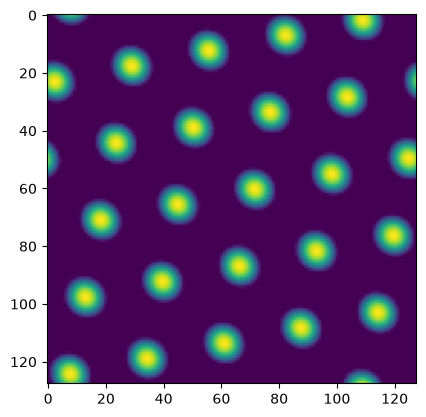

In [2]:
T = 500
dt = 0.5e-3
n = 128
box_size = 3
rng = np.random.default_rng(1)


net = ToroidZhang1996(n=n, dt=dt, periodicity=19, revolutions=2)
net.warm_up()
plt.imshow(net.s)

In [3]:
rat_walk = generate_random_walk(T, dt, box_size, rng=rng)
recording = net.run_simulation(rat_walk["vel"])

Running Simulation Steps: 100%|██████████| 1000000/1000000 [13:07<00:00, 1269.83it/s]


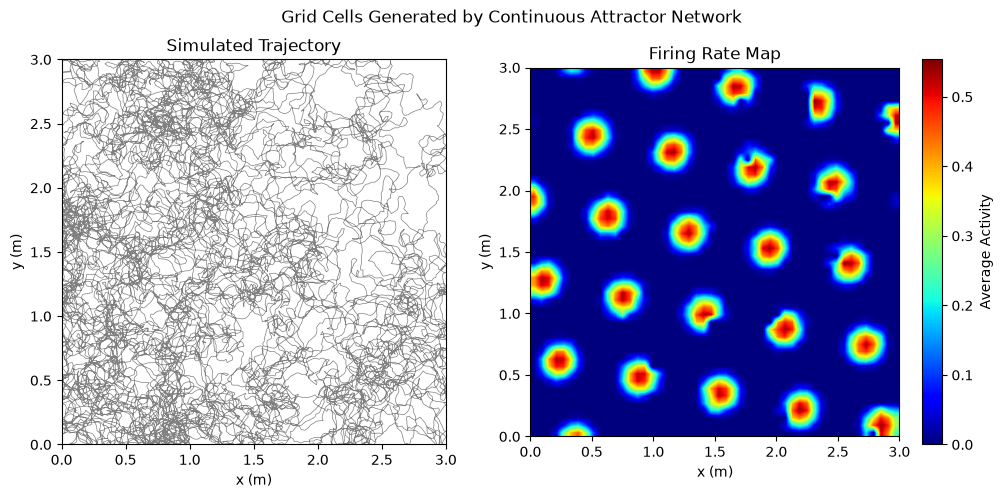

In [4]:
binned_activity, counts, edges = activity_map(
    rat_walk["pos"], recording["cell_recording"][:, 0]
)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": (1, 1.2)})
cb = ax[1].imshow(
    binned_activity.T,
    origin="lower",
    extent=[0, box_size, 0, box_size],
    cmap="jet",
    interpolation="bilinear",
)

ax[1].set_xlabel("x (m)")
ax[1].set_ylabel("y (m)")
ax[1].set_title("Firing Rate Map")
fig.colorbar(cb, ax=ax[1], label="Average Activity")

ax[0].set_title("Simulated Trajectory")
ax[0].plot(rat_walk["pos"][:, 0], rat_walk["pos"][:, 1], lw=0.5, color="gray")
ax[0].set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")
ax[0].set_xlim((0, box_size))
ax[0].set_ylim((0, box_size))
fig.suptitle("Grid Cells Generated by Continuous Attractor Network")
fig.savefig(os.path.join(PLOTS_DIR, "walk_2d_can_grid_cells.png"))